# The complete oil and gas value chain: where NeqSim fits

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/agent/complete-value-chain-lifecycle/notebooks/valuechain/complete_oil_and_gas_value_chain_with_neqsim.ipynb)

This is the **orientation notebook** for the NeqSim-Colab collection. It connects licence access,
subsurface characterization, reservoirs, wells, subsea and SURF, topsides, export, markets,
operations, emissions, and late-life decisions through one governed handoff chain.

It is intentionally broader and lighter than the detailed subject notebooks. The objective is to
show what each discipline receives, what it decides, what it passes forward, and where NeqSim is the
primary calculation engine versus a supporting thermodynamic service.

The synthetic case is public teaching material. It is not a reserves estimate, facility design,
operating instruction, commercial forecast, or decommissioning plan.


In [1]:
import importlib.util
import os
import subprocess
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/neqsim-complete-value-chain-matplotlib")
SUPPORT_PACKAGES = {
    "neqsim": "neqsim",
    "jpype": "jpype1",
    "matplotlib": "matplotlib",
    "numpy": "numpy",
    "pandas": "pandas",
    "scipy": "scipy",
}
missing_packages = [
    package
    for module, package in SUPPORT_PACKAGES.items()
    if importlib.util.find_spec(module) is None
]
if missing_packages:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--quiet",
            "--no-cache-dir",
            *missing_packages,
        ],
        check=True,
        timeout=900,
    )
print("Public-PyPI dependency gate passed.")


Public-PyPI dependency gate passed.


In [2]:
from importlib.metadata import version
import hashlib
import platform
from pathlib import Path
import subprocess

import jpype
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
    }
)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.4g}")

package_versions = pd.DataFrame(
    {
        "package": [
            "Python",
            "NeqSim",
            "JPype",
            "NumPy",
            "Pandas",
            "SciPy",
            "Matplotlib",
        ],
        "version": [
            platform.python_version(),
            version("neqsim"),
            version("jpype1"),
            version("numpy"),
            version("pandas"),
            version("scipy"),
            version("matplotlib"),
        ],
    }
)
display(package_versions)


,package,version
0,Python,3.12.13
1,NeqSim,3.16.0
2,JPype,1.7.1
3,NumPy,2.5.1
4,Pandas,3.0.5
5,SciPy,1.18.0
6,Matplotlib,3.11.1


## Reproducible public-PyPI NeqSim environment

The next cell uses the public-PyPI NeqSim package and records its version, Java runtime, packaged JAR
identity, SHA-256 digest, and a Java API smoke class.


In [3]:
import neqsim
from neqsim import jneqsim

neqsim_package_root = Path(neqsim.__file__).resolve().parent
neqsim_jars = sorted((neqsim_package_root / "lib").glob("neqsim-*.jar"))
if len(neqsim_jars) != 1:
    raise RuntimeError(
        f"Expected one packaged NeqSim JAR, found {len(neqsim_jars)}."
    )
neqsim_jar = neqsim_jars[0]
neqsim_jar_sha256 = hashlib.sha256(neqsim_jar.read_bytes()).hexdigest()

JClass = jpype.JClass
api_smoke_class = JClass("neqsim.process.equipment.separator.ThreePhaseSeparator")
api_smoke_name = str(api_smoke_class.class_.getName())
java_runtime = subprocess.run(
    ["java", "-version"],
    check=True,
    capture_output=True,
    text=True,
).stderr.splitlines()[0]

provenance_table = pd.DataFrame(
    {
        "item": [
            "NeqSim package version",
            "Artifact origin",
            "Packaged JAR",
            "JAR SHA-256",
            "Java runtime",
            "Java API smoke class",
        ],
        "resolved value": [
            version("neqsim"),
            "public PyPI",
            neqsim_jar.name,
            neqsim_jar_sha256,
            java_runtime,
            api_smoke_name,
        ],
    }
)
display(provenance_table)


,item,resolved value
0,NeqSim package version,3.16.0
1,Artifact origin,public PyPI
2,Packaged JAR,neqsim-3.16.0.jar
3,JAR SHA-256,aec6c0024ce55d3df810d61affc321ba99abeffb54110f...
4,Java runtime,"openjdk version ""17.0.19"" 2026-04-21"
5,Java API smoke class,neqsim.process.equipment.separator.ThreePhaseS...


## 1. Read the value chain as connected decisions

Each stage has a different model owner, but the boundaries are physical contracts rather than
organizational walls. Composition, pressure, temperature, phase rates, uncertainty, capacity,
availability, product specifications, emissions, and economics must remain traceable as they move
through the chain.

The central identity is a mass handoff:

$$

\dot{m}_{in}=\dot{m}_{gas}+\dot{m}_{oil}+\dot{m}_{water}

$$

NeqSim supplies fluid and process behavior at the handoffs. Python supplies data engineering,
statistics, optimization, visualization, uncertainty, schedules, reliability, and economics.


,stage,main decision,NeqSim role
0,Access and explore,Where and whether to explore,Fluid sample screen
1,Characterize and model,Resource range and production forecast,PVT and simulator-fluid model
2,Develop and drill,"Concept, wells, capacity, and schedule",Well/SURF/process design cases
3,Gather and transport,Deliverability and flow-assurance envelope,Multiphase hydraulics and flow assurance
4,Process and condition,"Saleable oil, gas, and managed water","Separation, compression, treatment, utilities"
5,Export and sell,"Quality, nominations, logistics, and value","Product quality, export energy, terminal states"
6,Operate and improve,"Availability, integrity, optimization, emissions","Digital twin, consequence, energy, accounting"
7,Cease and decommission,"Economic limit, safe isolation, and removal","Inventory, depressurization, flushing basis"


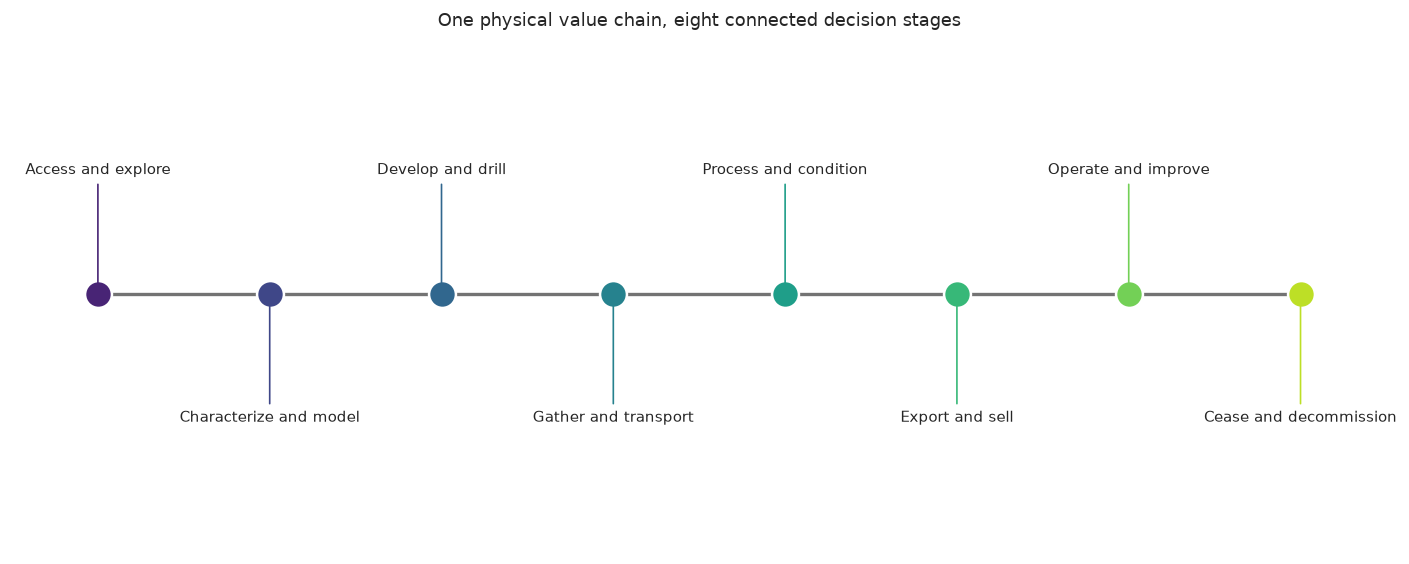

In [4]:
stages = pd.DataFrame(
    {
        "stage": [
            "Access and explore",
            "Characterize and model",
            "Develop and drill",
            "Gather and transport",
            "Process and condition",
            "Export and sell",
            "Operate and improve",
            "Cease and decommission",
        ],
        "main decision": [
            "Where and whether to explore",
            "Resource range and production forecast",
            "Concept, wells, capacity, and schedule",
            "Deliverability and flow-assurance envelope",
            "Saleable oil, gas, and managed water",
            "Quality, nominations, logistics, and value",
            "Availability, integrity, optimization, emissions",
            "Economic limit, safe isolation, and removal",
        ],
        "NeqSim role": [
            "Fluid sample screen",
            "PVT and simulator-fluid model",
            "Well/SURF/process design cases",
            "Multiphase hydraulics and flow assurance",
            "Separation, compression, treatment, utilities",
            "Product quality, export energy, terminal states",
            "Digital twin, consequence, energy, accounting",
            "Inventory, depressurization, flushing basis",
        ],
    }
)
display(stages)

fig, axis = plt.subplots(figsize=(12, 4.8))
x_positions = np.arange(len(stages))
y_positions = np.where(x_positions % 2 == 0, 0.62, 0.38)
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(stages)))

axis.plot(x_positions, np.full(len(stages), 0.5), color="0.45", linewidth=2)
for index, row in stages.iterrows():
    axis.scatter(
        index,
        0.5,
        s=260,
        color=colors[index],
        edgecolor="white",
        linewidth=1.5,
        zorder=3,
    )
    axis.annotate(
        row["stage"],
        xy=(index, 0.5),
        xytext=(index, y_positions[index]),
        ha="center",
        va="center",
        fontsize=9,
        arrowprops={"arrowstyle": "-", "color": colors[index]},
    )

axis.set_xlim(-0.5, len(stages) - 0.5)
axis.set_ylim(0.25, 0.75)
axis.set_title("One physical value chain, eight connected decision stages")
axis.axis("off")
plt.tight_layout()
plt.show()


## 2. One fluid becomes the common process contract

A representative reservoir stream is separated into gas, stabilized-liquid precursor, and produced
water. The calculation is deliberately compact: it establishes the phase and energy handoff used by
well, SURF, topside, export, produced-water, energy, emissions, and economic studies.

Detailed design remains in the linked specialist notebooks later in this notebook.


,stream,mass flow kg/h,pressure bara,temperature °C,next owner
0,export gas,2.528e+04,125,132.7,gas export and market
1,oil-processing feed,1.195e+05,65,72,oil stabilization and export
2,produced water,"5,174",65,72,produced-water treatment


,metric,value,unit
0,Mass residual,4.075e-14,fraction
1,Export-compressor power,886.5,kW


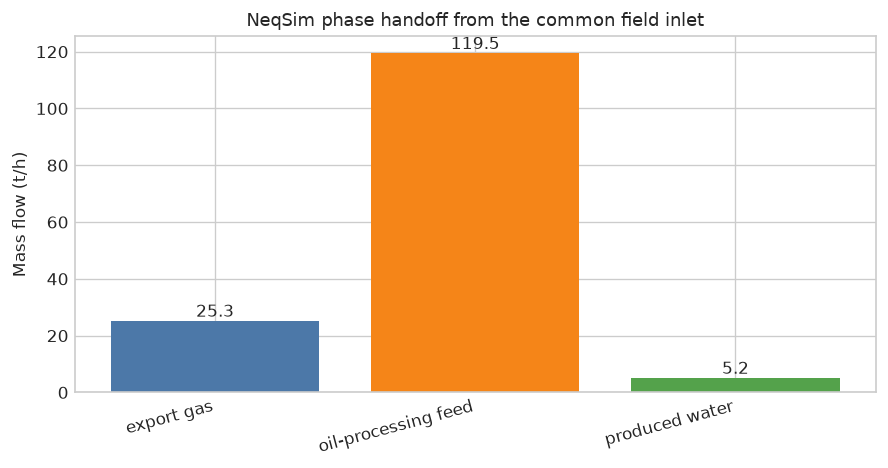

In [5]:
SystemSrkCPA = JClass("neqsim.thermo.system.SystemSrkCPAstatoil")
Stream = JClass("neqsim.process.equipment.stream.Stream")
ThreePhaseSeparator = JClass(
    "neqsim.process.equipment.separator.ThreePhaseSeparator"
)
Compressor = JClass("neqsim.process.equipment.compressor.Compressor")

feed_fluid = SystemSrkCPA(273.15 + 72.0, 65.0)
feed_composition = {
    "methane": 48.0,
    "ethane": 6.0,
    "propane": 4.0,
    "n-heptane": 20.0,
    "nC10": 12.0,
    "water": 10.0,
}
for component, amount in feed_composition.items():
    feed_fluid.addComponent(component, amount)
feed_fluid.setMixingRule(10)
feed_fluid.setMultiPhaseCheck(True)

wellstream = Stream("Field inlet", feed_fluid)
wellstream.setFlowRate(150_000.0, "kg/hr")
wellstream.run()

separator = ThreePhaseSeparator("HP three-phase separator", wellstream)
separator.run()
gas_stream = separator.getGasOutStream()
oil_stream = separator.getOilOutStream()
water_stream = separator.getWaterOutStream()

export_compressor = Compressor("Export compressor", gas_stream)
export_compressor.setOutletPressure(125.0)
export_compressor.setIsentropicEfficiency(0.78)
export_compressor.run()

phase_rates = np.array(
    [
        gas_stream.getFlowRate("kg/hr"),
        oil_stream.getFlowRate("kg/hr"),
        water_stream.getFlowRate("kg/hr"),
    ]
)
mass_residual = abs(phase_rates.sum() - wellstream.getFlowRate("kg/hr"))
relative_mass_residual = mass_residual / wellstream.getFlowRate("kg/hr")
compressor_power_kw = float(export_compressor.getPower("kW"))

handoff = pd.DataFrame(
    {
        "stream": ["export gas", "oil-processing feed", "produced water"],
        "mass flow kg/h": phase_rates,
        "pressure bara": [
            export_compressor.getOutletStream().getPressure("bara"),
            oil_stream.getPressure("bara"),
            water_stream.getPressure("bara"),
        ],
        "temperature °C": [
            export_compressor.getOutletStream().getTemperature("C"),
            oil_stream.getTemperature("C"),
            water_stream.getTemperature("C"),
        ],
        "next owner": [
            "gas export and market",
            "oil stabilization and export",
            "produced-water treatment",
        ],
    }
)
assert relative_mass_residual < 1.0e-8
assert compressor_power_kw > 0.0
display(handoff.round(2))
display(
    pd.DataFrame(
        {
            "metric": ["Mass residual", "Export-compressor power"],
            "value": [relative_mass_residual, compressor_power_kw],
            "unit": ["fraction", "kW"],
        }
    )
)

fig, axis = plt.subplots(figsize=(7.5, 4.0))
bars = axis.bar(
    handoff["stream"],
    handoff["mass flow kg/h"] / 1_000.0,
    color=["#4c78a8", "#f58518", "#54a24b"],
)
axis.bar_label(bars, fmt="%.1f")
axis.set_ylabel("Mass flow (t/h)")
axis.set_title("NeqSim phase handoff from the common field inlet")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


## 3. Field life couples disciplines that are often studied separately

Declining hydrocarbon deliverability and increasing water fraction move the dominant constraint from
reservoir/wells to compression, liquid processing, water handling, availability, and finally the
economic limit. Capacity utilization for service $j$ is

$$

U_j(t)=\frac{L_j(t)}{C_j}

$$

where $L_j$ is the time-dependent load and $C_j$ is available capacity. The largest utilization is
the active bottleneck. This reduced field-life model uses NeqSim's baseline phase split and specific
compression demand; a mature study would re-run the complete compositional process for each
reservoir realization and operating state.


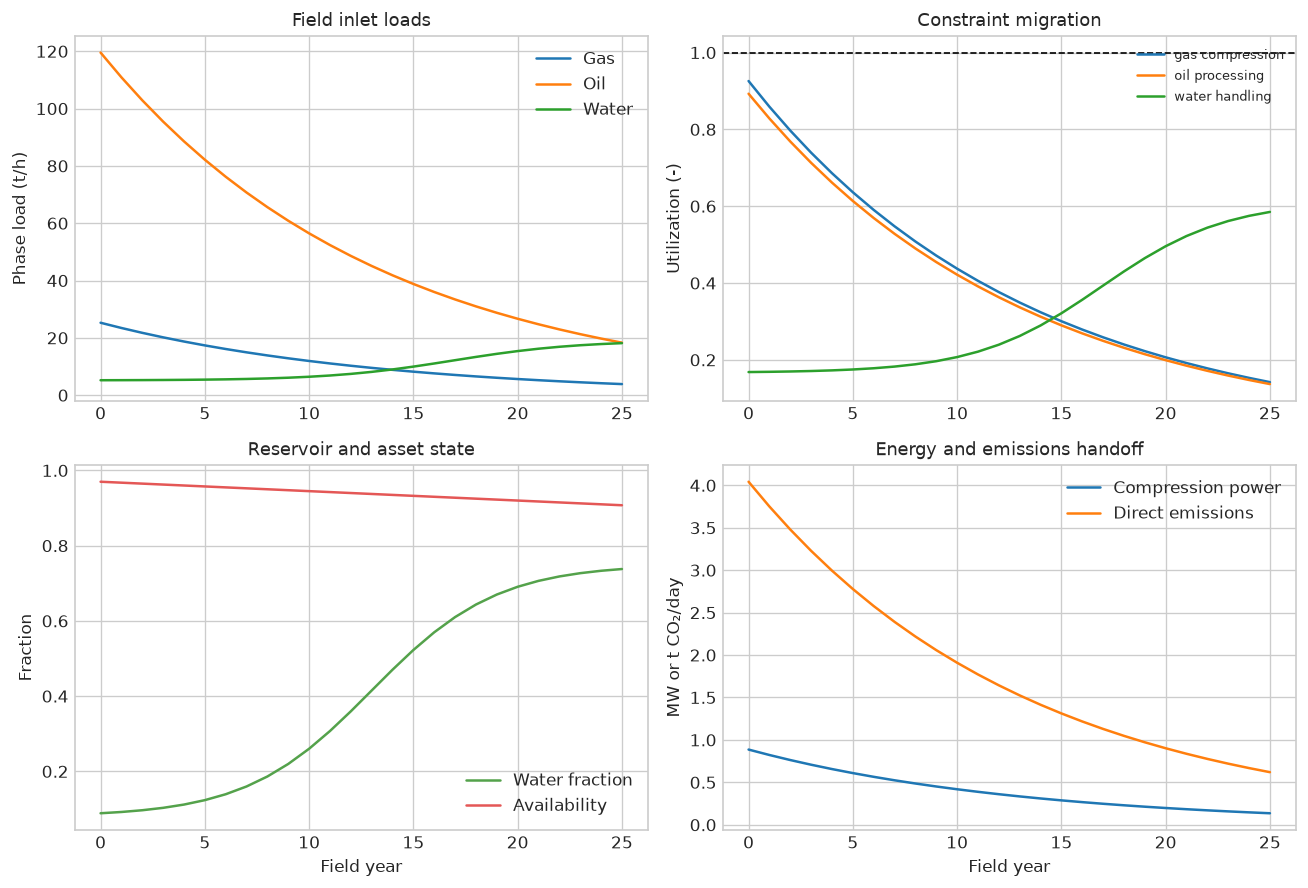

,year,gas t/h,oil t/h,water t/h,water fraction,availability,maximum utilization,active constraint,compression MW,direct emissions t/d
0,0,25.28,119.5,5.223,0.089,0.97,0.926,gas compression,0.886,4.042
5,5,17.38,82.16,5.431,0.124,0.958,0.636,gas compression,0.609,2.778
10,10,11.94,56.47,6.434,0.26,0.945,0.437,gas compression,0.419,1.909
15,15,8.207,38.81,9.973,0.523,0.932,0.321,water handling,0.288,1.312
20,20,5.641,26.67,15.39,0.691,0.92,0.496,water handling,0.198,0.902
25,25,3.877,18.33,18.16,0.738,0.908,0.585,water handling,0.136,0.62


In [6]:
field_year = np.arange(0, 26)
hydrocarbon_factor = np.exp(-0.075 * field_year)
water_fraction = 0.08 + 0.67 / (1.0 + np.exp(-(field_year - 13.0) / 3.0))
availability = np.clip(0.97 - 0.0025 * field_year, 0.88, 1.0)

base_gas_kg_h = phase_rates[0]
base_oil_kg_h = phase_rates[1]
base_water_kg_h = phase_rates[2]
gas_load = base_gas_kg_h * hydrocarbon_factor
oil_load = base_oil_kg_h * hydrocarbon_factor
water_load = base_water_kg_h * (1.0 - 0.08) / (1.0 - water_fraction)

capacities = {
    "gas compression": base_gas_kg_h * 1.08,
    "oil processing": base_oil_kg_h * 1.12,
    "water handling": base_water_kg_h * 6.0,
}
utilization = pd.DataFrame(
    {
        "gas compression": gas_load / capacities["gas compression"],
        "oil processing": oil_load / capacities["oil processing"],
        "water handling": water_load / capacities["water handling"],
    },
    index=field_year,
)
maximum_utilization = utilization.max(axis=1)
active_constraint = utilization.idxmax(axis=1)
compression_power_mw = compressor_power_kw * gas_load / base_gas_kg_h / 1_000.0
direct_emissions_t_d = compression_power_mw * 24.0 * 0.19

field_life = pd.DataFrame(
    {
        "year": field_year,
        "gas t/h": gas_load / 1_000.0,
        "oil t/h": oil_load / 1_000.0,
        "water t/h": water_load / 1_000.0,
        "water fraction": water_fraction,
        "availability": availability,
        "maximum utilization": maximum_utilization,
        "active constraint": active_constraint,
        "compression MW": compression_power_mw,
        "direct emissions t/d": direct_emissions_t_d,
    }
)

fig, axes = plt.subplots(2, 2, figsize=(11, 7.5))
axes[0, 0].plot(field_year, field_life["gas t/h"], label="Gas")
axes[0, 0].plot(field_year, field_life["oil t/h"], label="Oil")
axes[0, 0].plot(field_year, field_life["water t/h"], label="Water")
axes[0, 0].set(ylabel="Phase load (t/h)", title="Field inlet loads")
axes[0, 0].legend()

for column in utilization.columns:
    axes[0, 1].plot(field_year, utilization[column], label=column)
axes[0, 1].axhline(1.0, color="black", linestyle="--", linewidth=1)
axes[0, 1].set(ylabel="Utilization (-)", title="Constraint migration")
axes[0, 1].legend(fontsize=8)

axes[1, 0].plot(field_year, water_fraction, color="#54a24b", label="Water fraction")
axes[1, 0].plot(field_year, availability, color="#e45756", label="Availability")
axes[1, 0].set(xlabel="Field year", ylabel="Fraction", title="Reservoir and asset state")
axes[1, 0].legend()

axes[1, 1].plot(field_year, compression_power_mw, label="Compression power")
axes[1, 1].plot(field_year, direct_emissions_t_d, label="Direct emissions")
axes[1, 1].set(
    xlabel="Field year",
    ylabel="MW or t CO₂/day",
    title="Energy and emissions handoff",
)
axes[1, 1].legend()
plt.tight_layout()
plt.show()

display(field_life.iloc[::5].round(3))


## 4. Capability map: NeqSim is not meant to replace every discipline tool

The map below uses three roles:

- **2 — primary engine:** NeqSim directly calculates the thermodynamic or process result.
- **1 — supporting service:** NeqSim supplies properties, boundaries, or consequence calculations.
- **0 — external handoff:** another governed tool is primary; NeqSim receives or returns a contract.

This distinction helps readers understand both where NeqSim is powerful and where OPM Flow, ERT,
GIS, structural, drilling, reliability, market, scheduling, and cost tools remain necessary.


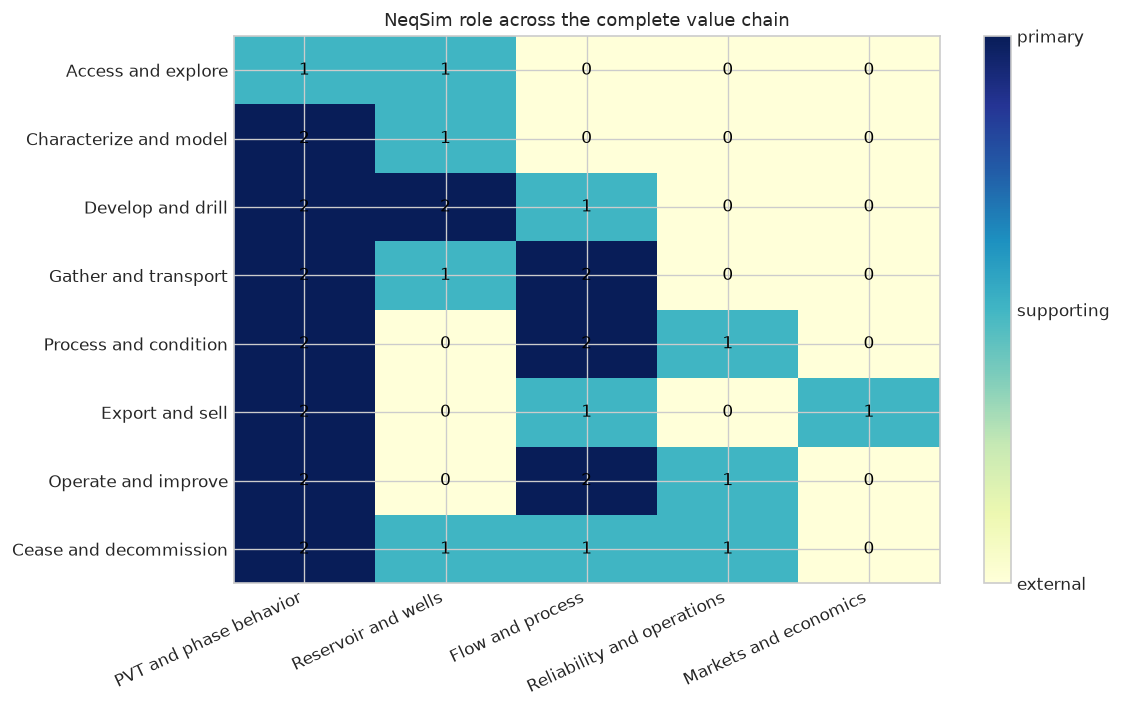

In [7]:
capabilities = [
    "PVT and phase behavior",
    "Reservoir and wells",
    "Flow and process",
    "Reliability and operations",
    "Markets and economics",
]
role_matrix = np.array(
    [
        [1, 1, 0, 0, 0],
        [2, 1, 0, 0, 0],
        [2, 2, 1, 0, 0],
        [2, 1, 2, 0, 0],
        [2, 0, 2, 1, 0],
        [2, 0, 1, 0, 1],
        [2, 0, 2, 1, 0],
        [2, 1, 1, 1, 0],
    ]
)

fig, axis = plt.subplots(figsize=(9.5, 6.0))
image = axis.imshow(role_matrix, cmap="YlGnBu", vmin=0, vmax=2, aspect="auto")
axis.set_xticks(np.arange(len(capabilities)), labels=capabilities)
axis.set_yticks(np.arange(len(stages)), labels=stages["stage"])
plt.setp(axis.get_xticklabels(), rotation=25, ha="right")
for row in range(role_matrix.shape[0]):
    for column in range(role_matrix.shape[1]):
        axis.text(
            column,
            row,
            str(role_matrix[row, column]),
            ha="center",
            va="center",
            color="black",
        )
axis.set_title("NeqSim role across the complete value chain")
colorbar = fig.colorbar(image, ax=axis, ticks=[0, 1, 2])
colorbar.ax.set_yticklabels(["external", "supporting", "primary"])
plt.tight_layout()
plt.show()


## 5. Recommended learning path through the detailed notebooks

1. **Fluid basis:** [modern fluid properties](../thermodynamics/modern_fluid_property_workflow.ipynb)
   and [PVT workflow](../PVT/pvt_workflow_from_lab_to_simulator.ipynb).
2. **Subsurface:** [rock flow](../reservoir/rock_flow_pore_to_field_neqsim.ipynb),
   [OPM Flow coupling](../reservoir/neqsim_opm_flow_blackoil_coupling.ipynb), and
   [uncertainty with ERT](../reservoir/ert_neqsim_integrated_field_development.ipynb).
3. **Wells and gathering:** [integrated wells](../well/integrated_wells_drilling_completion_lift_injection_intervention.ipynb),
   [subsea systems](../subseaequipment/subseaequipment.ipynb), and
   [minimum-flow hydraulics](../fluidflow/minimum_flow_long_multiphase_flowline.ipynb).
4. **Facilities:** [integrated oil and gas process](../process/oil_and_gas_Process_with_ngl_stabilizer_and_tex_process.ipynb),
   [produced water and chemicals](../production/produced_water_sand_chemicals_management.ipynb), and
   [energy and emissions](../power/neqsim_ecalc_integrated_energy_emissions.ipynb).
5. **Export and value:** [gas sales](../gasvaluechain/european_gas_sales_market_foundation.ipynb),
   [oil sales](../gasvaluechain/european_crude_oil_sales_foundation.ipynb), and
   [stochastic reservoir-to-market optimization](../reservoir/stochastic_reservoir_to_market_optimization.ipynb).
6. **Operate and retire:** [asset management](../operations/operations_asset_management_with_neqsim.ipynb)
   and the companion commissioning-to-decommissioning notebook in this section.

These links form a dependency-ordered curriculum rather than a claim that every notebook must be
completed before the next one.


In [8]:
validation = pd.DataFrame(
    {
        "check": [
            "Public-PyPI package and JAR identity",
            "Three-phase mass closure",
            "Finite compressor demand",
            "Finite field-life results",
            "Every value-chain stage mapped",
        ],
        "passed": [
            version("neqsim") == neqsim_jar.stem.removeprefix("neqsim-")
            and len(neqsim_jar_sha256) == 64,
            relative_mass_residual < 1.0e-8,
            np.isfinite(compressor_power_kw) and compressor_power_kw > 0.0,
            np.isfinite(field_life.select_dtypes("number").to_numpy()).all(),
            len(stages) == role_matrix.shape[0],
        ],
    }
)
if not validation["passed"].all():
    raise AssertionError(validation.to_string(index=False))
display(validation)

print(
    f"Baseline split: gas {phase_rates[0] / 1_000:.1f} t/h, "
    f"oil {phase_rates[1] / 1_000:.1f} t/h, "
    f"water {phase_rates[2] / 1_000:.1f} t/h."
)
print(
    f"The active constraint changes from {active_constraint.iloc[0]} "
    f"to {active_constraint.iloc[-1]} over the illustrative field life."
)


Baseline split: gas 25.3 t/h, oil 119.5 t/h, water 5.2 t/h.
The active constraint changes from gas compression to water handling over the illustrative field life.


,check,passed
0,Public-PyPI package and JAR identity,True
1,Three-phase mass closure,True
2,Finite compressor demand,True
3,Finite field-life results,True
4,Every value-chain stage mapped,True


## Interpretation and limitations

The useful result is the architecture: the same governed fluid and operating cases must connect
subsurface, wells, facilities, operations, products, emissions, and value. NeqSim is strongest at
thermodynamic, flow, process, energy, and physical-consequence boundaries; it should be composed
with specialist tools instead of being stretched into unsupported domains.

The field-life curves use simplified decline, water-fraction, capacity, emissions, and availability
assumptions. They demonstrate coupling and constraint migration, not forecast accuracy. A project
study should preserve internally consistent reservoir/process/economic realizations, measured
equipment envelopes, product specifications, uncertainty, and governed fiscal assumptions.
